# 03. Model Identification

This notebook implements the Random-Forest-based model identification pipeline for LLM attribution.

1. **Load features** from the pre-computed feature matrix
2. **Grouped 5-fold cross-validation** (GroupKFold by prompt_id)
3. **Train a final RF model** on a group-aware 80/20 split and evaluate
4. **Confusion matrix**
5. **Feature importance** analysis
6. **Cross-genre transfer** — leave-one-genre-out evaluation

In [8]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
from pathlib import Path

from src.analysis import AuthorshipClassifier, CORE_FEATURES
from src.visualization import StylometricPlotter

import warnings
warnings.filterwarnings('ignore')

## 1. Load Features

In [2]:
feature_path = Path('../data/processed/features.csv')
df = pd.read_csv(feature_path)
print(f"Loaded {len(df)} samples with {df.shape[1]} columns")

X = df[CORE_FEATURES]
y = df['label']
groups = df['prompt_id']   
genres = df['genre']       

print(f"\nFeatures shape: {X.shape}")
print(f"Core features ({len(CORE_FEATURES)}): {CORE_FEATURES}")
print(f"Unique prompts: {groups.nunique()}")
print(f"\nClass distribution:")
print(y.value_counts())

Loaded 360 samples with 23 columns

Features shape: (360, 19)
Core features (19): ['type_token_ratio', 'hapax_legomena_ratio', 'avg_word_length', 'stop_word_ratio', 'bigram_uniqueness_ratio', 'trigram_uniqueness_ratio', 'gunning_fog_index', 'avg_sentence_length', 'sentence_length_std', 'paragraph_count', 'avg_paragraph_length', 'pos_noun_ratio', 'pos_verb_ratio', 'pos_adj_ratio', 'pos_adv_ratio', 'comma_ratio', 'question_mark_ratio', 'avg_syntactic_depth', 'discourse_total_ratio']
Unique prompts: 40

Class distribution:
label
gpt-4-turbo    120
llama3         120
mistral        120
Name: count, dtype: int64


## 2. Grouped 5-Fold Cross-Validation

We evaluate Random Forest with **GroupKFold** by `prompt_id` to avoid prompt leakage — the same prompt family never appears in both train and test, so the classifier must rely on model-specific style rather than prompt-specific content.

In [5]:
rf_clf = AuthorshipClassifier(
    classifier_params={'n_estimators': 1000, 'random_state': 42}
)
rf_cv = rf_clf.cross_validate(X, y, cv=5, groups=groups)
print(f"Random Forest — CV macro-F1: {rf_cv['mean_f1']:.3f} +/- {rf_cv['std_f1']:.3f}")
print(f"  Fold scores: {[f'{s:.3f}' for s in rf_cv['all_scores']]}")

Random Forest — CV macro-F1: 0.751 +/- 0.042
  Fold scores: ['0.803', '0.777', '0.730', '0.680', '0.762']


## 3. Train Final RF Model and Evaluate

In [6]:
# Group-aware 80/20 train-test split — no prompt leakage
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
print(f"Train: {X_train.shape[0]} samples ({groups.iloc[train_idx].nunique()} prompts), "
      f"Test: {X_test.shape[0]} samples ({groups.iloc[test_idx].nunique()} prompts)")
print(f"Prompt overlap: {set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])}")

# Train RF on full training set
best_clf = AuthorshipClassifier(
    classifier_params={'n_estimators': 1000, 'random_state': 42}
)
best_clf.fit(X_train, y_train)

# Evaluate on test set
evaluation = best_clf.evaluate(X_test, y_test)
print(f"\nTest Accuracy:    {evaluation['accuracy']:.3f}")
print(f"Test F1 (macro):  {evaluation['f1_macro']:.3f}")
print(f"\nClassification Report:")
print(evaluation['classification_report'])

# Save model
best_clf.save('../data/processed/classifier_rf.joblib')
print("Model saved to ../data/processed/classifier_rf.joblib")

Train: 288 samples (32 prompts), Test: 72 samples (8 prompts)
Prompt overlap: set()

Test Accuracy:    0.764
Test F1 (macro):  0.757

Classification Report:
              precision    recall  f1-score   support

 gpt-4-turbo       0.87      0.83      0.85        24
      llama3       0.73      0.92      0.81        24
     mistral       0.68      0.54      0.60        24

    accuracy                           0.76        72
   macro avg       0.76      0.76      0.76        72
weighted avg       0.76      0.76      0.76        72

Model saved to ../data/processed/classifier_rf.joblib


## 4. Confusion Matrix

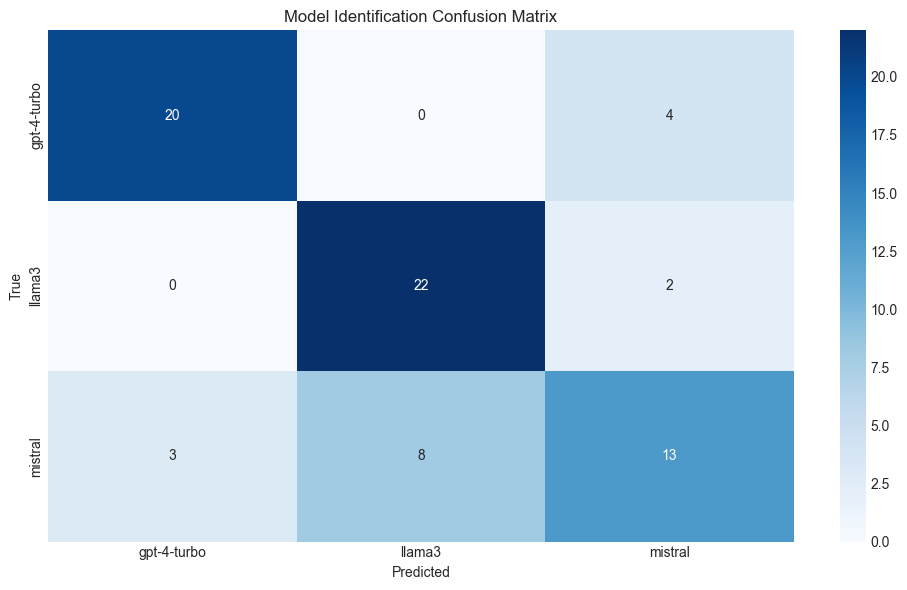

In [10]:
plotter = StylometricPlotter()
plotter.plot_confusion_matrix(
    np.array(evaluation['confusion_matrix']),
    labels=evaluation['classes']
);

## 5. Feature Importance

In [12]:
importance_df = best_clf.get_feature_importance()
print("Top 10 Discriminating Features:")
print(importance_df.head(10).to_string(index=False))

Top 10 Discriminating Features:
                 feature  importance
    avg_paragraph_length    0.115002
         paragraph_count    0.087378
trigram_uniqueness_ratio    0.074583
         avg_word_length    0.066395
        type_token_ratio    0.059582
     sentence_length_std    0.059474
         stop_word_ratio    0.053275
           pos_adv_ratio    0.052176
           pos_adj_ratio    0.051659
     avg_syntactic_depth    0.050439


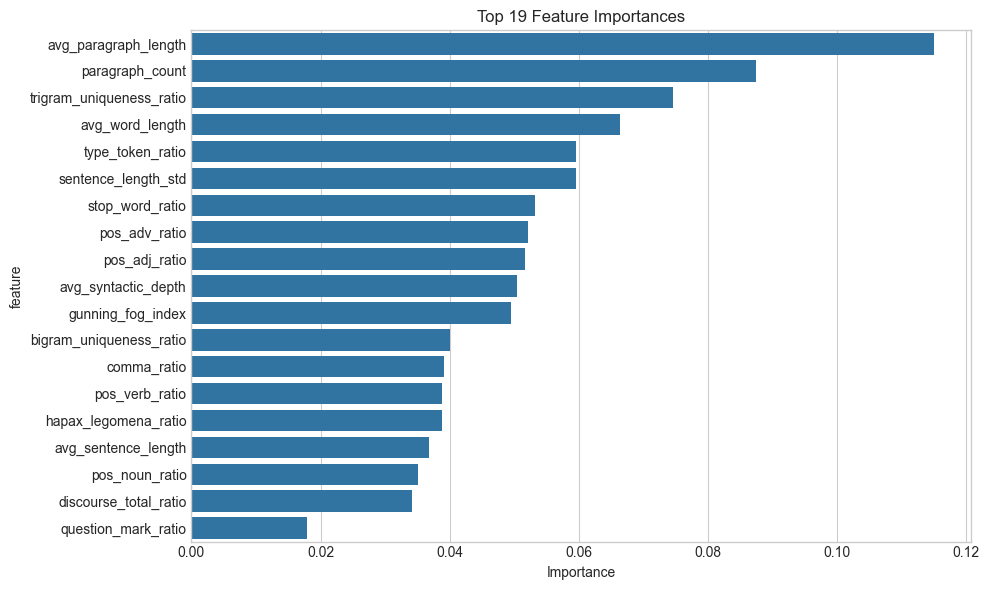

In [14]:
plotter.plot_feature_importance(importance_df);

## 6. Cross-Genre Transfer

**Leave-one-genre-out evaluation**: for each genre, we train a fresh Random Forest on all texts from the *other* genres and test on the held-out genre. This reveals whether a model's stylometric signature generalises across tasks.

In [ ]:
df_full = pd.read_csv('../data/processed/features.csv')
transfer_results = best_clf.run_cross_genre_transfer(df_full)
print("Cross-Genre Transfer Results (core features):")
print(transfer_results.to_string(index=False))
print(f"\nMean transfer accuracy: {transfer_results['accuracy'].mean():.3f}")
print(f"Worst genre: {transfer_results.loc[transfer_results['accuracy'].idxmin(), 'held_out_genre']}")

Cross-Genre Transfer Results (core features):
held_out_genre                          train_genres  accuracy  f1_macro  n_train  n_test
 argumentation      description, dialogue, narration  0.533333  0.440000      270      90
   description    argumentation, dialogue, narration  0.622222  0.635565      270      90
      dialogue argumentation, description, narration  0.411111  0.362009      270      90
     narration  argumentation, description, dialogue  0.666667  0.662615      270      90

Mean transfer accuracy: 0.558
Worst genre: dialogue


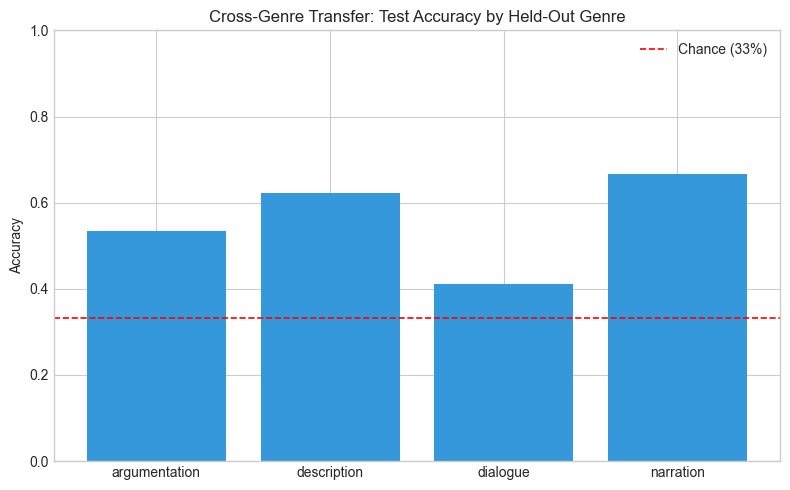

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(transfer_results['held_out_genre'], transfer_results['accuracy'], color='#3498db')
ax.axhline(1/3, color='red', linestyle='--', linewidth=1.2, label='Chance (33%)')
ax.set_ylabel('Accuracy')
ax.set_title('Cross-Genre Transfer: Test Accuracy by Held-Out Genre')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()